## Imports

In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Utils

In [122]:
def get_data_root():
  '''
    Ritorna il percorso della cartella contenente i dati in base all'ambiente di esecuzione.
  '''
  try:
      import google.colab
      from google.colab import drive

      try:
          drive.mount("/content/drive", force_remount=True)
          return "/content/drive/MyDrive/ColabContent/Data_analytics"
      except Exception:
          print("Drive non montabile")
          return "/content"

  except ImportError:
      return "../../data"

print(get_data_root())

Mounted at /content/drive
/content/drive/MyDrive/ColabContent/Data_analytics


## Global variables

In [123]:
DATA_ROOT = get_data_root()
DATASET_PATH = f"{DATA_ROOT}/Dataset2526/train.csv"
SEED = 42

Mounted at /content/drive


# Data visualization

In [124]:
data = pd.read_csv(DATASET_PATH)

print(f"Numero righe: {data.shape[0]}")
print(f"Numero colonne: {data.shape[1]}")

Numero righe: 148301
Numero colonne: 145


In [125]:
data.describe()

,loan_contract_approved_amount,loan_portfolio_total_funded,investor_side_funded_amount,loan_contract_interest_rate,loan_payment_installments_count,borrower_income_annual,borrower_dti_ratio,credit_delinquencies_2yrs,fico_score_low_bound,fico_score_high_bound,...,hardship_deferral_term_months,hardship_amount_total,hardship_duration_days,hardship_days_past_due,original_projected_additional_accrued_interest,hardship_payoff_balance,hardship_last_payment_amount_total,settlement_amount_total,settlement_percentage,settlement_term_months
count,147359.000000,147310.000000,147340.000000,147344.000000,147374.000000,1.472850e+05,147290.000000,147384.000000,147325.000000,147321.000000,...,847.000000,848.000000,844.000000,844.000000,646.000000,849.000000,844.000000,2547.000000,2551.000000,2541.000000
mean,15480.798022,15473.998642,15449.266497,14.338889,461.798822,7.741675e+04,19.138737,0.311560,696.809829,700.828088,...,2.999716,194.534885,2.999203,14.050984,559.551424,12762.413589,209.848233,5629.432803,47.989982,13.441965
std,9291.807670,9289.836708,9294.915845,6.029603,273.772443,7.456654e+04,14.737649,0.875384,37.740877,37.671663,...,0.086619,161.593364,0.078788,9.506587,460.401522,8060.637115,224.583257,4081.892282,7.247847,8.147653
min,505.191353,600.000000,0.000000,3.380729,7.610000,0.000000e+00,0.000000,0.000000,424.345347,415.715424,...,2.095783,5.560000,2.419556,0.000000,18.930000,519.830000,0.010000,186.000000,0.650000,0.000000
25%,8000.000000,8000.000000,8000.000000,9.930000,260.850000,4.600000e+04,12.130000,0.000000,670.000000,674.000000,...,3.000000,67.052500,3.000000,6.000000,196.230000,6292.110000,38.626251,2466.500000,45.000000,6.000000
50%,14000.000000,14000.000000,13975.000000,13.330000,395.090000,6.500000e+04,18.160000,0.000000,690.000000,694.000000,...,3.000000,154.213216,3.000000,16.000000,446.100000,11185.370000,137.835000,4769.470000,45.000000,15.000000
75%,20800.000000,20774.783151,20675.000000,17.860000,616.650000,9.200000e+04,24.900000,0.000000,715.000000,719.000000,...,3.000000,267.590000,3.000000,22.894363,764.505000,18043.780000,319.432500,7689.045000,50.000000,18.000000
max,49996.538547,49945.767116,50887.757837,39.623236,1782.235029,9.300086e+06,1121.484126,22.000000,1027.482299,1081.857580,...,3.733521,943.940000,3.491262,37.000000,2680.890000,36890.900000,1341.293091,30000.000000,100.000000,36.000000


### Duplicati

In [126]:
duplicates = data.duplicated().sum()
print("Sample duplicati: ", duplicates)

Sample duplicati:  0


### Percentuale dati mancanti per colonna

In [127]:
missing_pct = data.isnull().mean() * 100
missing_pct = missing_pct.sort_values(ascending=False)

print(missing_pct.head(40))

original_projected_additional_accrued_interest       99.564399
hardship_loan_status_label                           99.432910
hardship_end_date                                    99.431561
hardship_type_label                                  99.431561
hardship_last_payment_amount_total                   99.430887
hardship_duration_days                               99.430887
hardship_days_past_due                               99.430887
hardship_reason_label                                99.430213
hardship_payment_plan_start_date                     99.429539
hardship_start_date                                  99.429539
hardship_deferral_term_months                        99.428864
hardship_status_label                                99.428190
hardship_amount_total                                99.428190
hardship_payoff_balance                              99.427516
secondary_applicant_months_since_last_major_derog    98.374927
settlement_term_months                               98

### Tipi di dati

In [128]:
print(data.dtypes.value_counts())

float64    112
object      33
Name: count, dtype: int64


### Esplorazione variabili categoriche

In [129]:
categorical_cols = data.select_dtypes(include=['object']).columns

for col in categorical_cols:
    unique_vals = data[col].dropna().unique()
    print(f"Feature: {col}")
    # Se la colonna ha poche categorie, le stampiamo
    if len(unique_vals) < 15:
        print(f"Valori: {unique_vals}")
    print("-----------------------")

Feature: loan_contract_term_months
Valori: [' 36 months' ' 60 months']
-----------------------
Feature: borrower_profile_employment_length
Valori: ['10+ years' '2 years' '8 years' '1 year' '3 years' '6 years' '7 years'
 '9 years' '< 1 year' '5 years' '4 years']
-----------------------
Feature: borrower_housing_ownership_status
Valori: ['rent' 'mortgage' 'own' 'any' 'other' 'none']
-----------------------
Feature: borrower_income_verification_status
Valori: ['source verified' 'not verified' 'verified']
-----------------------
Feature: loan_issue_date
-----------------------
Feature: loan_status_current_code
Valori: ['fully paid' 'current' 'charged off' 'late (31-120 days)'
 'in grace period' 'late (16-30 days)'
 'does not meet the credit policy. status:fully paid'
 'does not meet the credit policy. status:charged off' 'default']
-----------------------
Feature: loan_payment_plan_flag
Valori: ['n' 'y']
-----------------------
Feature: loan_purpose_category
Valori: ['credit_card' 'debt_co

### Encoding variabili categoriche (solo per visualization)

In [130]:
# -----------------------------
# Binaria
# -----------------------------
binary_map = {'y':1, 'n':0}
binary_features = [
    'loan_payment_plan_flag',
    'hardship_flag_indicator',
    'debt_settlement_flag_indicator'
]

for f in binary_features:
    if f in data.columns:
        data[f + '_num'] = data[f].map(binary_map)

# -----------------------------
# Ordinale
# -----------------------------
# Employment length
employment_order = {
    '< 1 year':0,'1 year':1,'2 years':2,'3 years':3,'4 years':4,'5 years':5,
    '6 years':6,'7 years':7,'8 years':8,'9 years':9,'10+ years':10
}
if 'borrower_profile_employment_length' in data.columns:
    data['borrower_profile_employment_length_num'] = data['borrower_profile_employment_length'].map(employment_order)

# Income verification status
income_verif_order = {
    'not verified':0,
    'verified':1,
    'source verified':2
}
for f in ['borrower_income_verification_status','joint_income_verification_status']:
    if f in data.columns:
        data[f + '_num'] = data[f].map(income_verif_order)

# Loan grade
grade_order = {'A':0,'B':1,'C':2,'D':3,'E':4,'F':5,'G':6}
if 'grade' in data.columns:
    data['grade_numeric'] = data['grade'].map(grade_order)

# Loan contract term months
if 'loan_contract_term_months' in data.columns:
    data['loan_contract_term_months_num'] = data['loan_contract_term_months'].str.extract(r'(\d+)').astype(float)

# -----------------------------
# Nominale
# -----------------------------
nominal_features = [
    'borrower_housing_ownership_status',
    'loan_status_current_code',
    'loan_purpose_category',
    'borrower_address_state',
    'listing_initial_status',
    'hardship_type_label',
    'hardship_reason_label',
    'hardship_status_label',
    'hardship_loan_status_label',
    'disbursement_method_type',
    'settlement_status_label',
    'application_type_label'
]

# -----------------------------
# Date
# -----------------------------
date_features = [
    'loan_issue_date','credit_history_earliest_line','last_payment_date',
    'next_payment_date','last_credit_pull_date','secondary_applicant_earliest_credit_line',
    'hardship_start_date','hardship_end_date','hardship_payment_plan_start_date',
    'settlement_date'
]

for f in date_features:
    if f in data.columns:
        data[f] = pd.to_datetime(data[f])

/tmp/ipython-input-2656221398.py:75: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data[f] = pd.to_datetime(data[f])
/tmp/ipython-input-2656221398.py:75: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data[f] = pd.to_datetime(data[f])
/tmp/ipython-input-2656221398.py:75: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data[f] = pd.to_datetime(data[f])
/tmp/ipython-input-2656221398.py:75: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data[f

### Ricerca outlier

In [131]:

# Drop temporaneo delle feature con molti NaN
threshold = 0.5
missing_percent = data.isnull().mean()
cols_to_drop = missing_percent[missing_percent > threshold].index
outlier_df = data.copy()
outlier_df = outlier_df.drop(columns=cols_to_drop)

numeric_features = outlier_df.select_dtypes(include=np.number).columns.tolist()
stats_df = pd.DataFrame(index=numeric_features)

# IQR, std, min, max, mediana
stats_df['Q1'] = outlier_df[numeric_features].quantile(0.25)
stats_df['Q3'] = outlier_df[numeric_features].quantile(0.75)
stats_df['IQR'] = stats_df['Q3'] - stats_df['Q1']
stats_df['std'] = outlier_df[numeric_features].std()
stats_df['median'] = outlier_df[numeric_features].median()
stats_df['min'] = outlier_df[numeric_features].min()
stats_df['max'] = outlier_df[numeric_features].max()

# Severity Ratio (max rispetto alla mediana)
stats_df['severity_ratio'] = stats_df['max'] / (stats_df['median'] + 1)

# Conteggio outlier
outlier_counts = {}
for f in numeric_features:
    Q1, Q3, IQR = stats_df.loc[f, ['Q1', 'Q3', 'IQR']]
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    outlier_counts[f] = ((outlier_df[f] < lower) | (outlier_df[f] > upper)).sum()

stats_df['outlier_count'] = pd.Series(outlier_counts)

# Ordiniamo per severity_ratio
stats_df_sorted = stats_df.sort_values(by='severity_ratio', ascending=False)
stats_df_sorted[['median', 'max', 'outlier_count', 'severity_ratio']].head(20)

,median,max,outlier_count,severity_ratio
total_collection_amount,0.00,3.807570e+05,22002,380757.000000
delinquency_amount,0.00,6.590078e+04,493,65900.778787
outstanding_principal_balance,0.00,4.610663e+04,14475,46106.628858
outstanding_principal_investor_side,0.00,4.385532e+04,14504,43855.318533
recoveries_cash,0.00,3.232134e+04,14536,32321.340000
collection_recovery_fee,0.00,5.459400e+03,13923,5459.400000
total_received_late_fees,0.00,9.834300e+02,6357,983.430000
total_revolving_high_credit_limit,25000.00,9.999999e+06,8406,399.983961
revolving_balance,11401.00,2.560703e+06,8816,224.583670
borrower_income_annual,65000.00,9.300086e+06,7102,143.076045


### Visualizzazione grafico delle 20 feature individuate dall'IQR

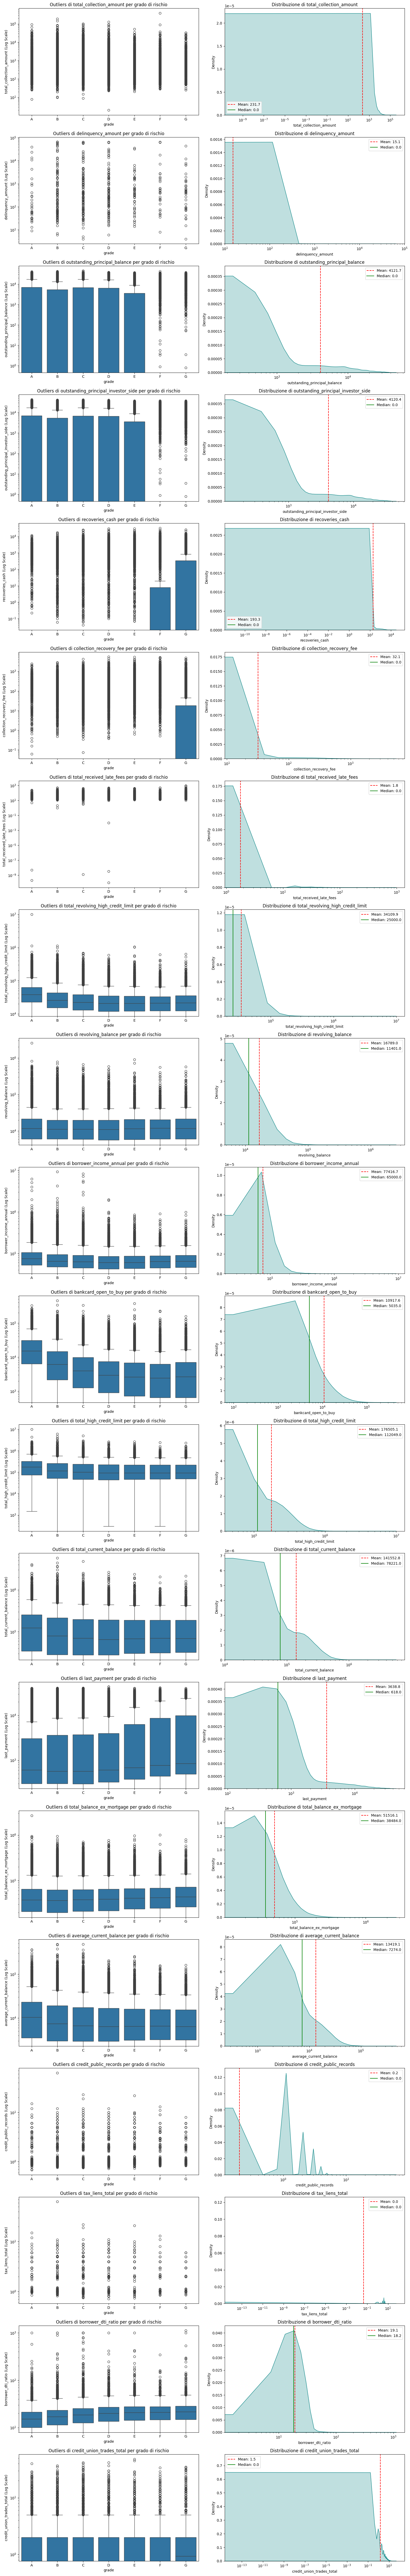

In [132]:
top20_features = stats_df_sorted.head(20).index.tolist()

fig, axes = plt.subplots(20, 2, figsize=(16, 100))

for i, col in enumerate(top20_features):
    # Density plot
    ax_dens = axes[i, 1]
    sns.kdeplot(data[col].dropna(), fill=True, ax=ax_dens, color='teal')

    # Linee per media e mediana
    mean, median = data[col].mean(), data[col].median()
    ax_dens.axvline(mean, color='red', linestyle='--', label=f'Mean: {mean:.1f}')
    ax_dens.axvline(median, color='green', linestyle='-', label=f'Median: {median:.1f}')

    # Boxplot
    ax_box = axes[i, 0]
    sns.boxplot(data=data, x='grade', y=col, ax=ax_box,
                order=sorted(data['grade'].dropna().unique()))

    # Scala logaritmica: se il max è 50 volte la mediana, usa scala log
    if data[col].max() > data[col].median() * 50:
        ax_dens.set_xscale('log')
        ax_box.set_yscale('log')
        ax_box.set_ylabel(f'{col} (Log Scale)')

    ax_dens.set_title(f'Distribuzione di {col}')
    ax_box.set_title(f'Outliers di {col} per grado di rischio')
    ax_dens.legend()

plt.tight_layout()
plt.show()

### Corss Analysis

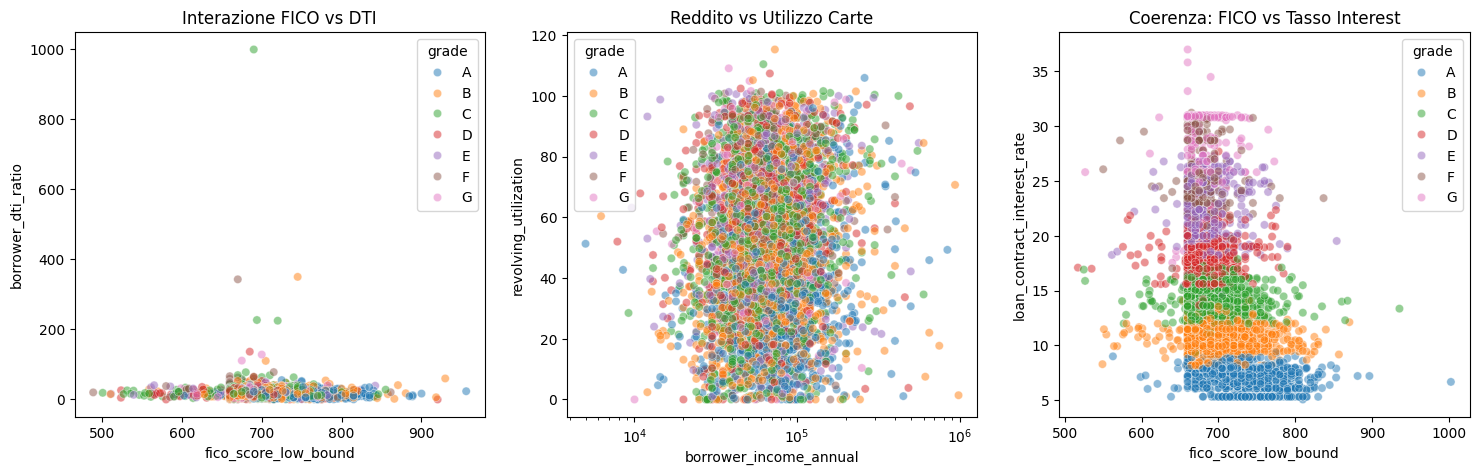

In [133]:

plt.figure(figsize=(18, 5))

# FICO vs DTI
plt.subplot(1, 3, 1)
sns.scatterplot(data=data.sample(5000), x='fico_score_low_bound', y='borrower_dti_ratio',
                hue='grade', alpha=0.5,
                hue_order=sorted(data['grade'].unique()))
plt.title('Interazione FICO vs DTI')

# Income vs Revolving Utilization (Capacità vs Stress)
plt.subplot(1, 3, 2)
sns.scatterplot(data=data.sample(5000), x='borrower_income_annual', y='revolving_utilization',
                hue='grade', alpha=0.5,
                hue_order=sorted(data['grade'].unique()))
plt.xscale('log')
plt.title('Reddito vs Utilizzo Carte')

# FICO vs Tasso di Interesse
plt.subplot(1, 3, 3)
if 'loan_contract_interest_rate' in data.columns:
    sns.scatterplot(data=data.sample(5000), x='fico_score_low_bound', y='loan_contract_interest_rate',
                    hue='grade', alpha=0.5,
                    hue_order=sorted(data['grade'].unique()))
    plt.title('Coerenza: FICO vs Tasso Interest')

plt.show()

### Distribuzione feature "Grade"

grade
B    0.254462
C    0.250039
A    0.178927
D    0.143337
E    0.081476
F    0.050735
G    0.041025
Name: proportion, dtype: float64


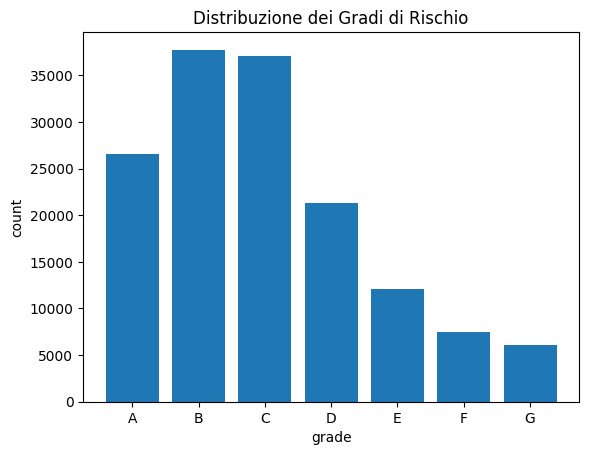

In [134]:
# Conta i valori
grades = data['grade'].dropna()
print(grades.value_counts(normalize=True)) # Mostra le percentuali

# Visualizza
unique_grades = sorted(grades.unique())
counts = [ (grades == g).sum() for g in unique_grades ]
plt.bar(unique_grades, counts)
plt.xlabel("grade")
plt.ylabel("count")
plt.title('Distribuzione dei Gradi di Rischio')
plt.show()

### Matrice di correlazione

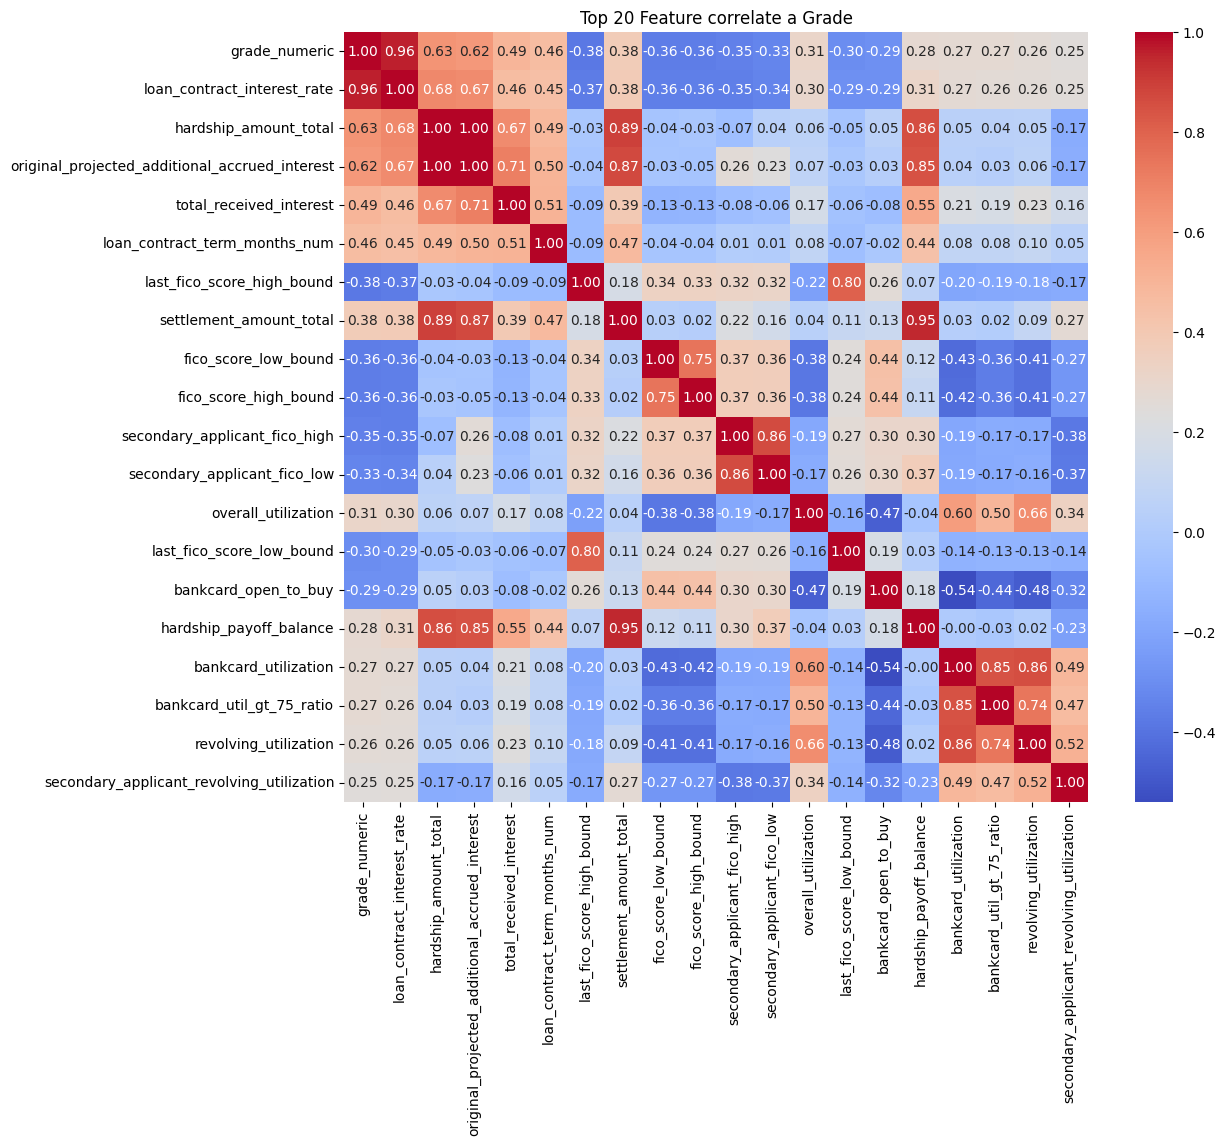

In [136]:
# Seleziona solo le colonne numeriche
numeric_data = data.select_dtypes(np.number)

# Calcola la correlazione con la variabile target numerica
corr_matrix = numeric_data.corr()
top_corr_features = corr_matrix['grade_numeric'].abs().sort_values(ascending=False).head(20).index

plt.figure(figsize=(12, 10))
sns.heatmap(numeric_data[top_corr_features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Top 20 Feature correlate a Grade')
plt.show()

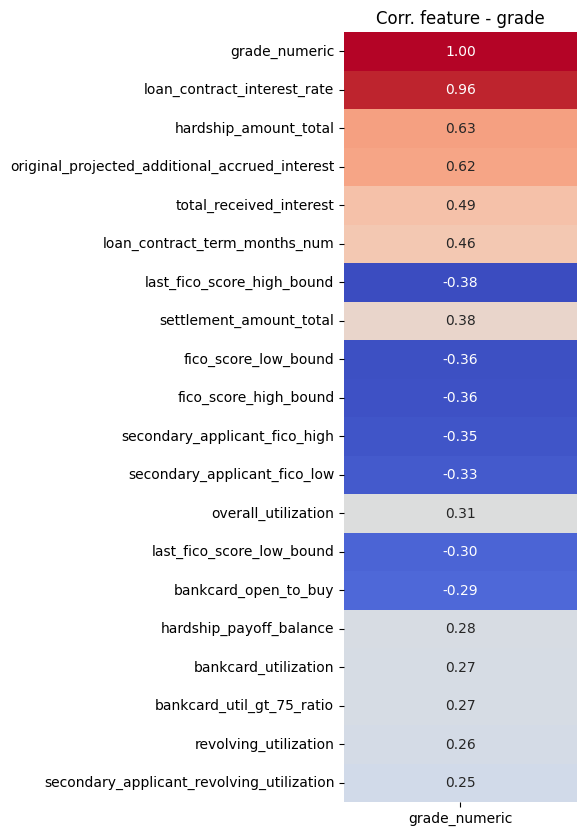

In [137]:
target_corr = corr_matrix['grade_numeric'].loc[top_corr_features]

plt.figure(figsize=(3, 10))
sns.heatmap(
    target_corr.to_frame(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    cbar=False
)
plt.title("Corr. feature - grade")
plt.show()

### Anlalisi temporale

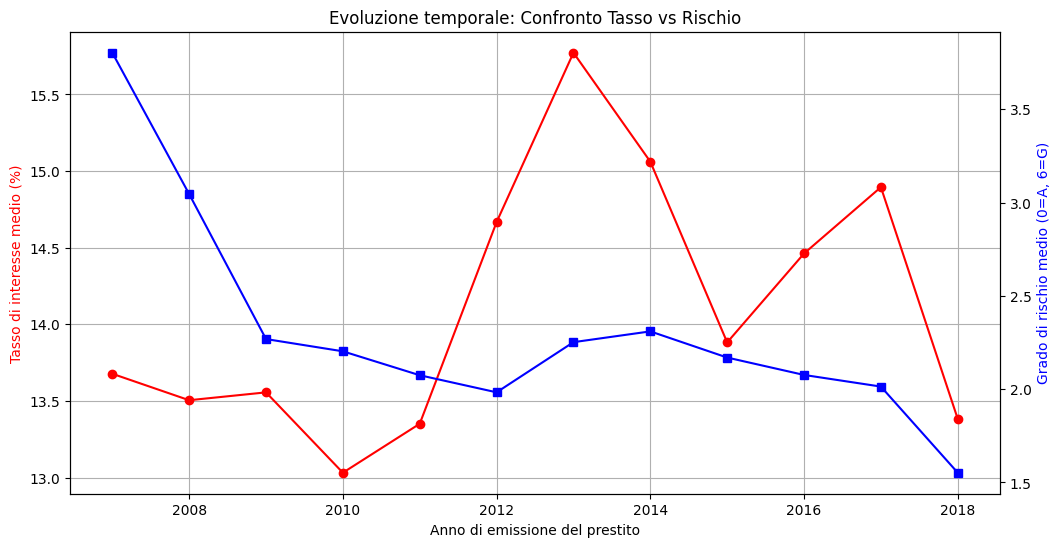

In [135]:
issue_year = data['loan_issue_date'].dt.year
interest_rate = data.groupby(issue_year)['loan_contract_interest_rate'].mean()
risk_trend = data.groupby(issue_year)['grade_numeric'].mean()

fig, ax1 = plt.subplots(figsize=(12, 6))

# Tasso di Interesse
ax1.set_xlabel('Anno di emissione del prestito')
ax1.set_ylabel('Tasso di interesse medio (%)', color='r')
ax1.plot(interest_rate.index, interest_rate.values, marker='o', color='r', label='Tasso di interesse')
ax1.grid(True)

# Grado di Rischio
ax2 = ax1.twinx()
ax2.set_ylabel('Grado di rischio medio (0=A, 6=G)', color='b')
ax2.plot(risk_trend.index, risk_trend.values, marker='s', color='b', label='Grado di rischio')

plt.title('Evoluzione temporale: Confronto Tasso vs Rischio')
plt.show()